## Шаг 1. EDA
- Изменение названий столбцов
- Проверка типов данных (чтобы даты были датами, числа числами и тд.) и их преобразование
- Проверка на наличие дубликатов и null-значений
- Осмотр данных и проверка на наличие выбросов.

In [45]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from scipy.stats import beta
from scipy.stats import norm
from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep,
    proportion_effectsize,
)
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_confint

from matplotlib import pyplot as plt

import duckdb

In [46]:
df = pd.read_csv('marketing_AB.csv', index_col='Unnamed: 0')
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [47]:
df.columns = df.columns.str.replace(' ', '_')

In [48]:
df.dtypes

user_id           int64
test_group       object
converted          bool
total_ads         int64
most_ads_day     object
most_ads_hour     int64
dtype: object

In [49]:
df['converted'] = df['converted'].astype(int)
df['test_group'] = df['test_group'].astype('category')
df['most_ads_day'] = df['most_ads_day'].astype('category')
df.dtypes #Все типы данных соответствуют бизнес-логике

user_id             int64
test_group       category
converted           int64
total_ads           int64
most_ads_day     category
most_ads_hour       int64
dtype: object

Преобразовали `converted` к целому типу, чтобы можно было производить вычисления, `test_group` и `most_ads_day` (тестовая группа, день недели) привели к категориальному типу.

In [50]:
df.shape

(588101, 6)

In [51]:
df['user_id'].duplicated().sum() #Дубликатов юзеров нет

np.int64(0)

In [52]:
df.isna().sum()

user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   user_id        588101 non-null  int64   
 1   test_group     588101 non-null  category
 2   converted      588101 non-null  int64   
 3   total_ads      588101 non-null  int64   
 4   most_ads_day   588101 non-null  category
 5   most_ads_hour  588101 non-null  int64   
dtypes: category(2), int64(4)
memory usage: 23.6 MB


In [54]:
df.describe() #Смущает максимальное значение total ads

,user_id,converted,total_ads,most_ads_hour
count,5.881010e+05,588101.000000,588101.000000,588101.000000
mean,1.310692e+06,0.025239,24.820876,14.469061
std,2.022260e+05,0.156850,43.715181,4.834634
min,9.000000e+05,0.000000,1.000000,0.000000
25%,1.143190e+06,0.000000,4.000000,11.000000
50%,1.313725e+06,0.000000,13.000000,14.000000
75%,1.484088e+06,0.000000,27.000000,18.000000
max,1.654483e+06,1.000000,2065.000000,23.000000


<Axes: >

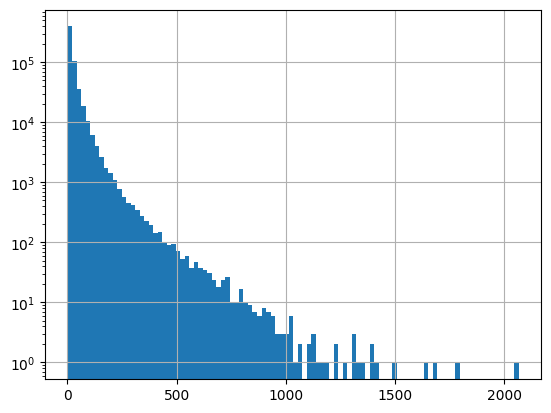

In [55]:
df['total_ads'].hist(bins=100, log=True) #Адекватно ли, что пользователь могу увидеть рекламу 2000 раз за время эксперимента?

In [56]:
df['total_ads'].quantile(0.99)

np.float64(202.0)

In [57]:
df[df['total_ads'] > df['total_ads'].quantile(0.99)]

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14
5,1137664,ad,0,734,Saturday,10
6,1116205,ad,0,264,Wednesday,13
10,1257223,ad,0,209,Wednesday,11
...,...,...,...,...,...,...
203231,1641663,ad,1,260,Wednesday,9
203283,1246560,ad,0,232,Wednesday,13
206009,1163495,ad,0,251,Thursday,13
206457,1008741,ad,1,253,Tuesday,13


В целом можем сказать, что какие-то пользователи и могли увидеть рекламу более 1000 раз. По крайней мере предпосылок к тому, чтобы убирать эти данные нет, поэтому оставляем как есть

In [58]:
df['test_group'].value_counts()

test_group
ad     564577
psa     23524
Name: count, dtype: int64

In [59]:
df['test_group'].value_counts(normalize=True) #psa видели 4% пользователей

test_group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

In [60]:
df['test_group'].value_counts(dropna=False)
df['most_ads_day'].value_counts(dropna=False)

most_ads_day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

## Шаг 2. АА-тест
Прежде чем приступать к A/B-тестированию, проверим, нет ли в данных смещения. Для этого проведём A/A-тест внутри группы `ad`, внутри `psa` и по всей выборке. Применять будем z-тест для пропорций: метрика `converted` бинарная, а выборка большая, поэтому по центральной предельной теореме распределение конверсии близко к нормальному. Уровень значимости $\alpha = 5\%$. На данных одной группы, где реального эффекта нет, тест не должен показать значимых различий; если же они найдутся — это повод перепроверить процедуру и данные. Заодно A/A даст представление о том, насколько конверсия может отклоняться по чисто случайным причинам.

In [61]:
#Для того, чтобы понимать, на сколько может случайно отклоняться значение converted, проведем АА-тест
df_aa = duckdb.sql(''' 
                   SELECT hash(user_id) % 2 AS bucket,
                   COUNT(*) AS n,
                   SUM(converted) AS convertions,
                   AVG(converted) AS mean
                   FROM df
                   WHERE test_group = 'ad'
                   GROUP BY bucket
                   ''').df()

df_aa

,bucket,n,convertions,mean
0,0,282507,7153.0,0.025320
1,1,282070,7270.0,0.025774


In [62]:
#Проверим, что средние выборок одной и той же генеральной совокупности равны
alpha = 0.05
z, p = proportions_ztest(df_aa['convertions'], df_aa['n'], alternative='two-sided')

if alpha >= p:
    print('reject H0')
else:
    print('Not reject H0')
print(f'z = {z:.2}, p_value = {p:.2}')

Not reject H0
z = -1.1, p_value = 0.28


In [63]:
df_aa['%_conv'] = df_aa['convertions'] / df_aa['n'] * 100
(df_aa['%_conv'][0] - df_aa['%_conv'][1]) / df_aa['%_conv'][0] 
#Можем принять отколнение конверии в районе 1.8% за случайные колебания

np.float64(-0.01793137511175081)

In [64]:
df_aa = duckdb.sql(''' 
                   SELECT hash(user_id) % 2 AS bucket,
                   COUNT(*) AS n,
                   SUM(converted) AS convertions,
                   AVG(converted) AS mean
                   FROM df
                   WHERE test_group = 'psa'
                   GROUP BY bucket
                   ''').df()

alpha = 0.05
z, p = proportions_ztest(df_aa['convertions'], df_aa['n'], alternative='two-sided')
print(f'z = {z:.2}, p_value = {p:.2}')

if alpha >= p:
    print('reject H0')
else:
    print('Not reject H0')

df_aa['%_conv'] = df_aa['convertions'] / df_aa['n'] * 100
(df_aa['%_conv'][0] - df_aa['%_conv'][1]) / df_aa['%_conv'][0] 

z = 0.64, p_value = 0.52
Not reject H0


np.float64(0.059874149626473784)

In [65]:
df_aa = duckdb.sql(''' 
                   SELECT hash(user_id) % 2 AS bucket,
                   COUNT(*) AS n,
                   SUM(converted) AS convertions,
                   AVG(converted) AS mean
                   FROM df
                   GROUP BY bucket
                   ''').df()

alpha = 0.05
z, p = proportions_ztest(df_aa['convertions'], df_aa['n'], alternative='two-sided')

if alpha >= p:
    print('reject H0')
else:
    print('Not reject H0')
print(f'z = {z:.2}, p_value = {p:.2}')

df_aa['%_conv'] = df_aa['convertions'] / df_aa['n'] * 100
(df_aa['%_conv'][0] - df_aa['%_conv'][1]) / df_aa['%_conv'][0] 

Not reject H0
z = -0.95, p_value = 0.34


np.float64(-0.015457683731713454)

В результате получили, что значимых различий внутри групп нет, можем приступать к самому АБ-тестированию.

## Шаг 3. АБ-тест
**Гипотезы A/B-теста** (односторонний критерий, уровень значимости $\alpha = 0.05$):

$$
\begin{aligned}
H_0&: p_{ad} \le p_{psa} \quad (\text{реклама не повышает конверсию}) \\
H_1&: p_{ad} > p_{psa} \quad (\text{реклама повышает конверсию})
\end{aligned}
$$

где $p_{ad}$ и $p_{psa}$ — истинные конверсии тестовой и контрольной групп.

In [66]:
df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14


In [67]:
df_ab = duckdb.sql("""
                   SELECT test_group,
                    SUM(converted) AS total_conv,
                    COUNT(*) AS n,
                    AVG(converted) AS mean
                    FROM df
                    GROUP BY test_group
                   """).df()

df_ab

,test_group,total_conv,n,mean
0,ad,14423.0,564577,0.025547
1,psa,420.0,23524,0.017854


In [68]:
z, p = proportions_ztest(df_ab['total_conv'], df_ab['n'], alternative='larger')
print(f'z = {z:.2}, p_value = {p:.2}')

z = 7.4, p_value = 8.5e-14


In [69]:
if p <= alpha:
    print('reject H0')
else:
    print('Not reject H0')

reject H0


Видим, что есть статистически значимое различие между $p_{ad}$ и $p_{psa}$. Однако важно заметить, что выборка psa сильно меньше, чем ad и, скорее всего у различия конверсий будет большой довреительный интервал.

In [70]:
lift = (df_ab['mean'][0] - df_ab['mean'][1])/df_ab['mean'][1] * 100
lift #Средняя конверсия с рекламой на 43% превышает конверсию без неё

np.float64(43.085064022225836)

In [71]:
n_ad, n_psa = df_ab['n'][0], df_ab['n'][1]
c_ad, c_psa = df_ab['total_conv'][0], df_ab['total_conv'][1]

low, high = confint_proportions_2indep(
    count1=c_ad, nobs1=n_ad,
    count2=c_psa, nobs2=n_psa,
    compare='diff',
    alpha=alpha
)

print(f'Истинное значение разницы конверсий лежит в диапазоне от {low*100:.2} до {high*100:.2} п.п.')

Истинное значение разницы конверсий лежит в диапазоне от 0.59 до 0.94 п.п.


In [72]:
low, high = confint_proportions_2indep(
    count1=c_ad, nobs1=n_ad,
    count2=c_psa, nobs2=n_psa,
    compare='ratio',
    alpha=alpha
)

print(f'Истинный прирост конверсии лежит в диапазоне от {round((low-1)*100,2)}% до {round((high-1)*100,2)}%')

Истинный прирост конверсии лежит в диапазоне от 29.83% до 57.34%


Нижняя граница 95% доверительного интервала для относительного прироста (lift) составляет 30%. То есть с вероятностью 95% реклама повышает конверсию не менее чем на 30% относительно контроля; в абсолютном выражении разница $p_{ad} - p_{psa}$ — не менее ~0.6 п.п. (ДИ [0.59, 0.94] п.п.). Таким образом, различие не только статистически значимо, но и практически существенно.

## Шаг 4. Хи-квадрат и h-критерий Коэна
Дополнительно можно исследовать связь между принадлежностью пользователя к одной из тестовых групп и вероятностью его конверсии. Для этого применим тест хи-квадрат. 
**Гипотезы для критерия хи-квадрат** (тест независимости, $\alpha = 0.05$):

$$
\begin{aligned}
H_0&: \text{конверсия и группа независимы (связи нет)} \\
H_1&: \text{конверсия и группа зависимы (связь есть)}
\end{aligned}
$$

Также при помощи Cohen’s h измерим величину влияния рекламы на конверсию

In [73]:
cont = pd.crosstab(df['test_group'], df['converted'])
chi2, p, dof, expectd = chi2_contingency(cont) 
print(f'chi2 = {chi2:.1f}, p_value = {p:.2}, dof = {dof}')

chi2 = 54.0, p_value = 2e-13, dof = 1


In [74]:
chi2_nc, *_ = chi2_contingency(cont, correction=False)
print(chi2_nc, z**2) #Хи-квадрат должен быть примерно равен z-статистике в квадрате.

54.318051591383124 54.31805159138317


In [75]:
if p <= alpha:
    print('reject H0')
else:
    print('Not reject H0')

reject H0


In [76]:
h = proportion_effectsize(df_ab['mean'][0], df_ab['mean'][1])
print(f"Cohen's h = {h:.3}") #Малый эффект

Cohen's h = 0.053


Тест хи-квадрат подтвердил связь: конверсия и группа зависимы ($\chi^2 \approx 54$, p-value ≈ 2e-13). Это независимое подтверждение результата z-теста.

Cohen's h ≈ 0.053 — по шкале Коэна это очень малый эффект (ориентиры: 0.2 — малый, 0.5 — средний, 0.8 — большой). Причина в том, что Коэн измеряет степень влияния в абсолютных величинах. Конверсия сама по себе небольшая, поэтому и Cohen's h получился маленьким. В дальнейшем будем использовать это значение для расчёта MDE. 

## Шаг 5. Мощность и MDE

Оценим чувствительность нашего дизайна: какой минимальный эффект (MDE) мы способны уверенно обнаружить при заданных размерах групп, $\alpha = 5\%$ и мощности 80%.

In [77]:
analysis = NormalIndPower()

ratio = n_psa / n_ad
power = 0.8
mde = analysis.solve_power(effect_size=None,
                           nobs1=n_ad,
                           ratio=ratio,
                           alpha=alpha,
                           power=power,
                           alternative='larger')
print(f'MDE = {mde:.3}')

MDE = 0.0165


In [78]:
z_a, z_b = norm.ppf(1 - alpha), norm.ppf(power)
p2 = df_ab['mean'][1]
mde_diff = (z_a + z_b) * np.sqrt(p2*(1-p2) * (1/n_ad + 1/n_psa))
print(f'MDE = {mde_diff*100:.2f} п.п.  ({mde_diff/p2*100:.0f}% lift)')

MDE = 0.22 п.п.  (12% lift)


MDE составил ≈ 0.017 в единицах Cohen's h, что соответствует ≈ 0.22 п.п. абсолютной разницы или ≈ 12% относительного прироста. Наблюдаемый эффект (+43%, 0.77 п.п.) примерно втрое больше MDE, то есть у нас был запас на обнаружение изменений.

## Шаг 6. Байесовский A/B

Частотный тест ответил, есть ли различие конверсий. Байесовский подход поможет ответить на вопрос: с какой вероятностью реклама лучше и каков ожидаемый прирост? Для этого воспользуемся Бета-распределением. Построим распределения конверсий при имеющихся данных, из этих распределений возьмём 100000 выборок и посчитаем в скольких случаях конверсия теста будет больше, чем у контроля, на основании этого строим вероятность.

In [79]:
post_ad = beta(1 + c_ad, 1 + n_ad - c_ad) #Строим распределения
post_psa = beta(1 + c_psa, 1 + n_psa - c_psa)

print(post_ad.mean(), post_psa.mean())

0.025548240370258192 0.01789509478874437


In [80]:
N = 100000

s_ad = post_ad.rvs(N, random_state=42) #Извлекаем выборки
s_psa = post_psa.rvs(N, random_state=43)

p_better = (s_ad > s_psa).mean() #Считаем вероятность и относительный прирост
uplift = (s_ad - s_psa)/s_psa

print(f'Конверсия с рекламой превышает конверсию без неё с вероятностью {p_better}')
print(f'Ожидаемый прирост = {uplift.mean()*100:.1f}%')
print(f'95% "байесовский" интервал прироста: {np.percentile(uplift, [2.5, 97.5])*100}')
print(f'P(lift > 10%) = {(uplift > 0.10).mean():.3f}')

Конверсия с рекламой превышает конверсию без неё с вероятностью 1.0
Ожидаемый прирост = 43.1%
95% "байесовский" интервал прироста: [30.08536872 57.58310125]
P(lift > 10%) = 1.000


$P(p_{ad} > p_{psa}) \approx 1.0$ — практически со стопроцентной уверенностью конверсия рекламы выше. Ожидаемый прирост ≈ +43%, а 95% байесовский интервал (credible interval) ≈ [30%, 58%] почти совпал с частотным доверительным интервалом.

## Шаг 7. Исследование причинности
Мы поняли, что реклама может быть полезна бизнесу. Теперь хочется понять, есть ли смысл показывать больше рекламы людям (и тратить больше денег на её распространение). Иначе говоря: растёт ли конверсия с ростом числа просмотренных пользователем реклам. Кажется, что да, но давайте исследуем, человек покупает, потому что видит много рекламы или видит много рекламы, потому что покупает?

In [81]:
df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14


In [82]:
df_dynamics = duckdb.sql("""
                         SELECT test_group,
                         CASE 
                         WHEN total_ads <= 5 THEN '1-5'
                         WHEN total_ads <= 25 THEN '5-25' 
                         WHEN total_ads <= 50 THEN '25-50'
                         WHEN total_ads <= 100 THEN '50-100'
                         ELSE '>100'
                         END AS ad_group,
                         AVG(converted) * 100 AS conv
                         FROM df
                         GROUP BY test_group, ad_group
                         ORDER BY test_group, MIN(total_ads)
""").df()

df_dynamics

,test_group,ad_group,conv
0,ad,1-5,0.251233
1,ad,5-25,0.842701
2,ad,25-50,3.542104
3,ad,50-100,11.631068
4,ad,>100,17.135214
5,psa,1-5,0.279863
6,psa,5-25,0.881705
7,psa,25-50,2.658112
8,psa,50-100,5.774420
9,psa,>100,11.881188


In [83]:
cross = df_dynamics.pivot(index='ad_group', columns='test_group', values='conv')
cross

test_group,ad,psa
ad_group,,
1-5,0.251233,0.279863
25-50,3.542104,2.658112
5-25,0.842701,0.881705
50-100,11.631068,5.774420
>100,17.135214,11.881188


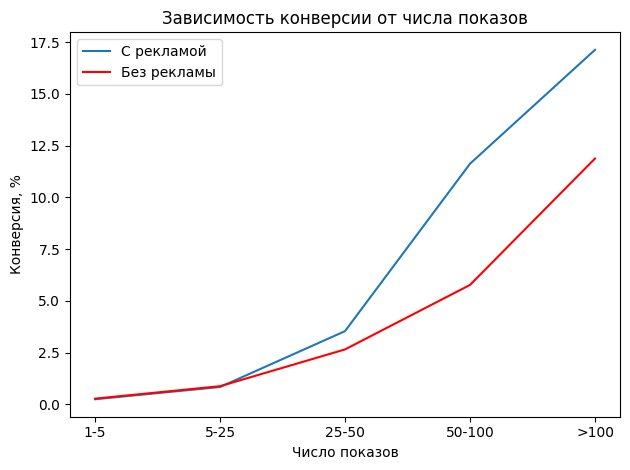

In [84]:
fig, ax = plt.subplots()

ax.plot(df_dynamics[df_dynamics['test_group'] == 'ad']['ad_group'],
        df_dynamics[df_dynamics['test_group'] == 'ad']['conv'],
        label='С рекламой')
ax.plot(df_dynamics[df_dynamics['test_group'] == 'psa']['ad_group'],
        df_dynamics[df_dynamics['test_group'] == 'psa']['conv'],
        color='red',
        label='Без рекламы')
ax.set_title('Зависимость конверсии от числа показов')
ax.set_xlabel('Число показов')
ax.set_ylabel('Конверсия, %')
ax.legend()

plt.tight_layout()
plt.show()

Как видим, с ростом числа просмотров, растет конверсия не только у тех кто видел рекламу, но и у тех, кто видел psa. Это означает, что мы не можем утверждать: с ростом просмотров рекламы растут продажи. Причинно-следственной связи нет и это нужно будет исследовать при разработке маркетинговой стратегии

## Шаг 8. Визуализация

Соберём ключевые выводы в визуальный блок из четырёх графиков:

1. Конверсия по группам с 95% ДИ
2. Конверсия от числа показов по группам
3. Распределение `total_ads` в лог-шкале
4. Байесовские апостериорные распределения — два почти не пересекающихся «колокола»: наглядно видно $P(ad>psa)\approx 1$ и бо́льшую неопределённость `psa`.

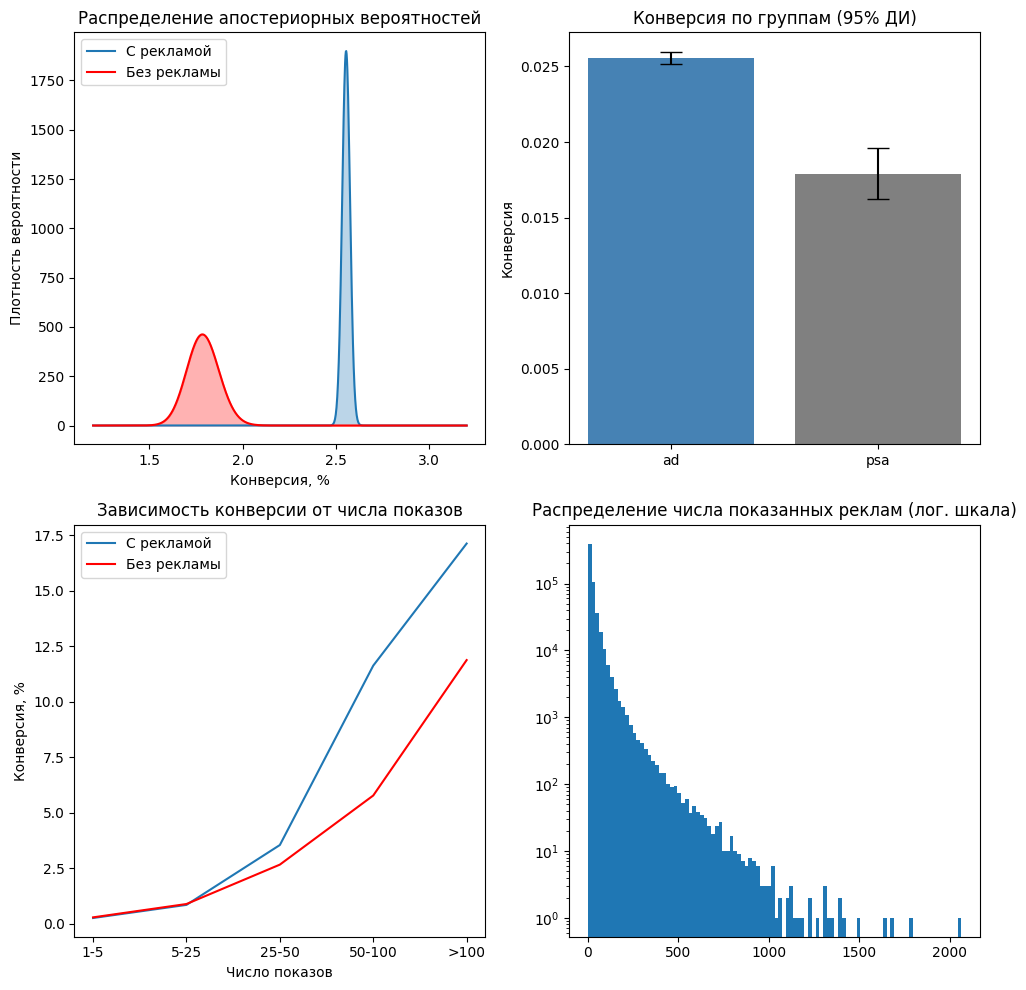

In [85]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

ax[0, 0].plot(x*100, post_ad.pdf(x),  label='С рекламой')
ax[0, 0].plot(x*100, post_psa.pdf(x), label='Без рекламы', color='red')
ax[0, 0].fill_between(x*100, post_psa.pdf(x), alpha=0.3, color='red')
ax[0, 0].fill_between(x*100, post_ad.pdf(x),  alpha=0.3)
ax[0, 0].set_xlabel('Конверсия, %')
ax[0, 0].set_title('Распределение апостериорных вероятностей')
ax[0, 0].set_ylabel('Плотность вероятности')
ax[0, 0].xaxis.set_major_locator(plt.MaxNLocator(5))
ax[0, 0].legend()

ax[0, 1].bar(['ad', 'psa'], rates, yerr=yerr, capsize=8, color=['steelblue', 'grey'])
ax[0, 1].set_ylabel('Конверсия')
ax[0, 1].set_title('Конверсия по группам (95% ДИ)')

ax[1, 0].plot(df_dynamics[df_dynamics['test_group'] == 'ad']['ad_group'],
        df_dynamics[df_dynamics['test_group'] == 'ad']['conv'],
        label='С рекламой')
ax[1, 0].plot(df_dynamics[df_dynamics['test_group'] == 'psa']['ad_group'],
        df_dynamics[df_dynamics['test_group'] == 'psa']['conv'],
        color='red',
        label='Без рекламы')
ax[1, 0].set_title('Зависимость конверсии от числа показов')
ax[1, 0].set_xlabel('Число показов')
ax[1, 0].set_ylabel('Конверсия, %')
ax[1, 0].legend()

ax[1, 1].hist(df['total_ads'], bins=100, log=True)
ax[1, 1].set_title('Распределение числа показанных реклам (лог. шкала)')

plt.tight_layout()
plt.show()

## Выводы

Основной результат. Реклама значимо ($\alpha=0.05$) и практически существенно повышает конверсию. Конверсия тестовой группы `ad` — 2.55%, контрольной группы — 1.79%. Эффект: +0.77 п.п. абсолютно (ДИ [0.59, 0.94] п.п.) и +43% относительно контроля (ДИ [30%, 57%]). Результат подтверждён тремя независимыми методами: z-тест ($z=7.4$, $p\approx 8.5\times10^{-14}$), хи-квадрат ($\chi^2 = 54$) и байесовский A/B ($P(ad>psa)\approx 1$).

Причинность. Так как группа назначалась случайно, оценка причинная: реклама даёт ~43% прироста конверсии. Связи конверсии с `total_ads`, днём недели и часом — корреляционные и причинно не интерпретируются.

Дизайн. A/A-тесты подтвердили корректность процедуры — ложных срабатываний нет. Анализ мощности показал, что при данном сплите мы уверенно ловим эффект от ~12% lift; наблюдённые +43% сильно выше, поэтому результат надёжен.

Рекомендация. Раскатывать рекламу: эффект положительный, значимый и с высокой вероятностью окупается ($P(\text{lift}>10\%)\approx 1$). При повторном тесте стоит сбалансировать сплит для более точной оценки величины эффекта.